<hr style="border:2px solid #CC00FF;">

<!-- Contenedor ultra-compatible. Usamos 'height' en lugar de 'width' para lograr simetría visual -->
<p align="center">
    <a href="https://medellin.unal.edu.co" target="_blank">
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" height="75" alt="Logo UNAL">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://minaslap.net/?redirect=0" target="_blank">
        <img src="https://minaslap.net/pluginfile.php/1/core_admin/logo/0x200/1770226238/Logo%20MinasLAP-3%20%281%29.png" height="75" alt="Logo MinasLAP">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://micampus.unal.edu.co" target="_blank">
        <img src="https://micampus.unal.edu.co/pluginfile.php/1/theme_almondb/sliderimage1/1788871931/Slider_1.png" height="75" alt="Logo MiCampus">
    </a>
</p>

<!-- Títulos usando alineación clásica compatible con IDEs -->
<h1 align="center">Optimización e IA 2026-2S</h1>
<h2 align="center">Práctica 1</h2>
<h3 align="center">Parte 1: Optimización de funciones usando búsqueda de grilla y búsqueda aleatoria</h3>
<p align="center">
    Departamento de Ciencias de la Computación y de la Decisión<br>
    Facultad de Minas<br>
    Universidad Nacional de Colombia<br>
    Docente: Maria Constanza Torres Madronero
</p>

<div id="conte"></div>
<hr style="border:2px solid #CC00FF;">

**Elaborado por:** _Kevin Ferney Hidalgo Higuita_

**Correo:** _kfhidalgoh@unal.edu.co_

**Fecha de elaboración:** _12 de septiembre de 2026_

**Fecha última modificación:** _12 de septiembre de 2026_

**Repositorio:** [![GitHub Repository](https://img.shields.io/badge/repository-GitHub-181717.svg)](https://github.com/KevinHidalgoDS/optimizacion-ia)

*Nota: el tema del navegador para visualizar HTML puede afectar el comportamiento de la presentación.*

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import rand
from src.utils import logger as log

logger = log.LOGGER
config = log.CONFIG
logger.info("Python %s on %s", sys.version, sys.platform)

%matplotlib inline

2026-09-15 05:33:53 [INFO] Python 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)] on win32


Encuentre el valor mínimo de las siguientes funciones empleando la búsqueda por grilla y la aleatoria. Para cada una de las funciones, muestre su gráfica e imprima el valor óptimo.

1. $f\left(x,y\right)=0.26\left(x^{2}+y^{2}-0.48xy\right)\;para\:x,y\in\left[-10,10\right]$
2. $f\left(x,y\right)=-\cos\left(x\right)\cos\left(y\right)\exp\left\{ -\left(\left(x-\pi\right)^{2}+\left(y-\pi\right)^{2}\right)\right\} \;para\:x,y\in\left[-10,10\right]$
3. $f\left(x,y\right)=\left(x^{2}+y-11\right)^{2}+\left(x+y^{2}-7\right)^{2}\;para\:x,y\in\left[-5,5\right]$

## Función objetivo ecuación 1

In [6]:
def f(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Calcula el valor de la función f(x, y).

    Args:
        x: Primer argumento, en el intervalo [-10, 10].
        y: Segundo argumento, en el intervalo [-10, 10].

    Returns:
        Valor de f(x, y).

    Raises:
        ValueError: Si x o y están fuera del intervalo [-10, 10].
    """
    if np.any((x < -10) | (x > 10)):
        raise ValueError("Los valores de x deben estar en [-10, 10].")
    if np.any((y < -10) | (y > 10)):
        raise ValueError("Los valores de x deben estar en [-10, 10].")

    return 0.26 * (x**2 + y**2 - 0.48 * x * y)

Generación de 100 puntos línealmente espaciados entre -10 y 10

In [10]:
x_lineal = np.linspace(-10, 10, 100)
y_lineal = np.linspace(-10, 10, 100)

X, Y = np.meshgrid(x_lineal, y_lineal)
Z = f(X, Y)


print("\n" + "=" * 45)
print("Evaluación:")
for i in range(20):
    print('f(%.3f, %.3f) = %.3f' % (x_lineal[i], y_lineal[i], Z[i,i]))
print("\n" + "=" * 45)


Evaluación:
f(-10.000, -10.000) = 39.520
f(-9.798, -9.798) = 37.939
f(-9.596, -9.596) = 36.391
f(-9.394, -9.394) = 34.875
f(-9.192, -9.192) = 33.391
f(-8.990, -8.990) = 31.939
f(-8.788, -8.788) = 30.520
f(-8.586, -8.586) = 29.133
f(-8.384, -8.384) = 27.778
f(-8.182, -8.182) = 26.456
f(-7.980, -7.980) = 25.165
f(-7.778, -7.778) = 23.907
f(-7.576, -7.576) = 22.681
f(-7.374, -7.374) = 21.488
f(-7.172, -7.172) = 20.327
f(-6.970, -6.970) = 19.198
f(-6.768, -6.768) = 18.101
f(-6.566, -6.566) = 17.036
f(-6.364, -6.364) = 16.004
f(-6.162, -6.162) = 15.004



Gráfica

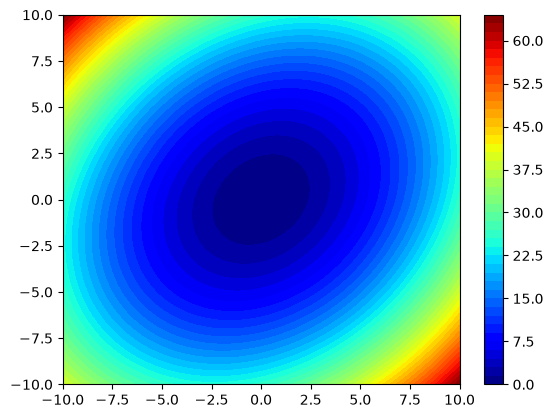

In [12]:
plt.contourf(X, Y, Z, levels=50, cmap=plt.cm.jet)
plt.colorbar()

Generación de grilla

In [15]:
x_sample = np.arange(-3.0, 3.0, 0.6)
y_sample = np.arange(-3.0, 3.0, 0.7)

xt, yt = np.meshgrid(x_sample, y_sample)

#Calculamos la funcion
feval_t = f(xt, yt)

Busqueda en grilla

In [18]:
# inicializamos variables
f_opt = feval_t[0,0]
best_x, best_y = 0, 0

for i in range(feval_t.shape[0]):  # recorrido en fila
  for j in range(feval_t.shape[1]):  # recorrido en columnas
    if feval_t[i][j]<f_opt:
      f_opt=feval_t[i][j]
      best_x = i
      best_y = j

x_opt = xt[best_x, best_y]
y_opt = yt[best_x, best_y]

print("\n" + "="*35)
print("🏆 RESULTADOS DE LA OPTIMIZACIÓN 🏆")
print("="*35)
print(f"🔸 Coordenada X : {x_opt:.5f}")
print(f"🔸 Coordenada Y : {y_opt:.5f}")
print("-" * 35)
print(f"🎯 Valor Óptimo : {f_opt:.5f}")
print("="*35 + "\n")


🏆 RESULTADOS DE LA OPTIMIZACIÓN 🏆
🔸 Coordenada X : 0.00000
🔸 Coordenada Y : -0.20000
-----------------------------------
🎯 Valor Óptimo : 0.01040



In [19]:
# 1. Encontrar el índice (plano) del valor mínimo en la matriz
indice_minimo = np.argmin(feval_t)

# 2. Convertir ese índice plano en coordenadas de fila y columna (best_x, best_y)
best_x, best_y = np.unravel_index(indice_minimo, feval_t.shape)

# Extraer los valores
f_opt = feval_t[best_x, best_y]
x_opt = xt[best_x, best_y]
y_opt = yt[best_x, best_y]

# El nuevo print amigable
print(f"📍 Punto óptimo: x = {x_opt:.4f}, y = {y_opt:.4f}")
print(f"🎯 Valor óptimo: {f_opt:.4f}")

📍 Punto óptimo: x = 0.0000, y = -0.2000
🎯 Valor óptimo: 0.0104


gráfica

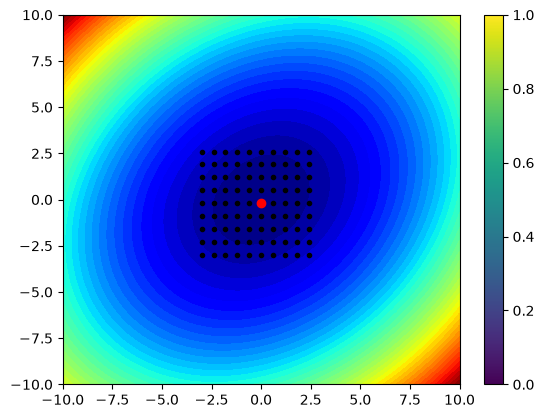

In [20]:
plt.contourf(X, Y, Z, levels=50, cmap='jet')
plt.scatter(xt,yt,c='black',marker='.')
plt.scatter(xt[best_x][best_y],yt[best_x][best_y],c='red')
plt.colorbar()

In [ ]:
def f(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Calcula la función de forma vectorizada.

    Args:
        x: Valores de x en el intervalo [-10, 10].
        y: Valores de y en el intervalo [-10, 10].

    Returns:
        Valores de la función para cada par de x e y.

    Raises:
        ValueError: Si algún valor de x o y está fuera del intervalo
            [-10, 10].
    """
    if np.any((x < -10) | (x > 10)):
        raise ValueError("Los valores de x deben estar en [-10, 10].")

    if np.any((y < -10) | (y > 10)):
        raise ValueError("Los valores de y deben estar en [-10, 10].")

    return -np.cos(x) * np.cos(y) * np.exp(
        -((x - np.pi) ** 2 + (y - np.pi) ** 2)
    )



In [ ]:
def funcion_himmelblau(x, y):
    """Calcula la función de Himmelblau.

    Esta función matemática se define como:
    f(x, y) = (x**2 + y - 11)**2 + (x + y**2 - 7)**2
    El dominio estándar de evaluación suele ser x, y ∈ [-5, 5].

    Args:
        x (float o numpy.ndarray): Coordenada o arreglo de coordenadas en el eje X.
        y (float o numpy.ndarray): Coordenada o arreglo de coordenadas en el eje Y.

    Returns:
        float o numpy.ndarray: El valor o arreglo de valores resultantes
        tras evaluar la función.
    """
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2


# ==========================================
# Ejemplo de uso vectorizado en el dominio [-5, 5]
# ==========================================
if __name__ == "__main__":
    # 1. Crear arreglos lineales en el rango [-5, 5] con 100 puntos cada uno
    x_lineal = np.linspace(-5, 5, 100)
    y_lineal = np.linspace(-5, 5, 100)

    # 2. Crear una cuadrícula bidimensional (grid) a partir de los arreglos
    X, Y = np.meshgrid(x_lineal, y_lineal)

    # 3. Evaluar la función de manera vectorizada (sin bucles for)
    Z = funcion_himmelblau(X, Y)

    print(f"Dimensiones de la matriz resultante (Z): {Z.shape}")
    print(f"Valor mínimo encontrado en la cuadrícula: {np.min(Z):.4f}")